In [36]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf


pd.options.mode.chained_assignment = None
warnings.filterwarnings('ignore')

In [37]:
df = pd.read_csv('source/FReDA4.csv')
df["Group4"] = None

In [38]:
# Satisfied
df.loc[df['Group3'] == 'Couple Satisfaction', 'Group4'] = 'Couple Satisfaction'

# Deprived groups
df.loc[df['Group1'] == 'SubGroup-DeprivedBoth', 'Group4'] = 'Deprived_Both'
df.loc[df['Group1'] == 'SubGroup-DeprivedMe', 'Group4'] = 'Deprived_Me'
df.loc[df['Group1'] == 'SubGroup-DeprivedPartner', 'Group4'] = 'Deprived_Partner'
#
# Oversaturated groups
df.loc[df['Group1'] == 'SubGroup-OversaturatedBoth', 'Group4'] = 'Oversaturated_Both'
df.loc[df['Group1'] == 'SubGroup-OversaturatedMe', 'Group4'] = 'Oversaturated_Me'
df.loc[df['Group1'] == 'SubGroup-OversaturatedPartner', 'Group4'] = 'Oversaturated_Partner'

df.loc[df['Group3'] == 'Couple Mixed', 'Group4'] = 'Mixed couple'

In [39]:
df = df.rename(columns={
    'Relationship Satisfaction': 'Relationship_Satisfaction',
    'Relationship Length (years)': 'Relationship_Length_years',
})

In [40]:
def collapse_kde_into_bins(kde_df, bins=[0, 1, 2, 3, 4, 5, 6]):
    df = kde_df.copy()
    N = df["N_total"].iloc[0]

    dx = df["x"].diff().median()

    df["bin"] = pd.cut(df["x"], bins=bins, labels=range(len(bins) - 1), right=False)

    out = (
        df.groupby("bin")
        .apply(lambda g: pd.Series({
            "density_sum": (g["density"] * dx).sum(),
        }))
        .reset_index()
    )
    return out

In [41]:
mask1 = (
    df.groupby('CoupleId')['Frequency_F']
    .nunique()
    .eq(1)
)

mask2 = (
    df.groupby('CoupleId')['Desire_F']
    .nunique()
    .eq(1)
)

df['Match_Frequency'] = df['CoupleId'].map(
    lambda cid: 'Aligned' if mask1.get(cid, False) else 'Misaligned'
    # lambda cid: 1 if mask1.get(cid, False) else 0
)
df['Match_Frequency_n'] = df['CoupleId'].map(
    # lambda cid: 'Alignment' if mask1.get(cid, False) else 'Disalignment'
    lambda cid: 1 if mask1.get(cid, False) else 0
)

df['Match_Desire'] = df['CoupleId'].map(
    lambda cid: 'Aligned' if mask2.get(cid, False) else 'Misaligned'
    # lambda cid: 1 if mask2.get(cid, False) else 0
)

df['Match_Desire_n'] = df['CoupleId'].map(
    # lambda cid: 'Alignment' if mask2.get(cid, False) else 'Disalignment'
    lambda cid: 1 if mask2.get(cid, False) else 0
)

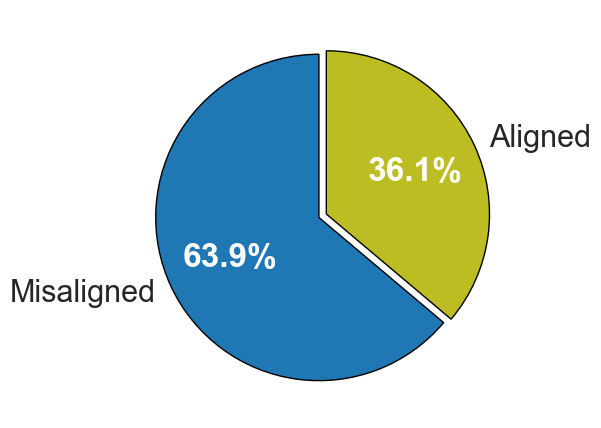

In [42]:
sns.set_context("poster")

custom_colors = ["#1f77b4", "#bcbd22"]

wedges, texts, autotexts = plt.pie(
    x=df["Match_Frequency_n"].value_counts(),
    labels=["Misaligned", "Aligned"],
    colors=custom_colors,
    autopct='%.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1},
    explode=[0.05, 0],
    # textprops={'color': 'white', 'fontweight': 'bold'}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.savefig('output/img/Alignment3.png', dpi=600, transparent=True, bbox_inches='tight')

In [43]:
(df[df['Group3'] == "Couple Satisfaction"]['Match_Frequency'].value_counts(normalize=True) * 100).round(1)

# df2 = df[df["Match_Frequency"] == "Aligned"].copy()
# df3 = df[df["Match_Desire"] == "Aligned"].copy()

Match_Frequency
Misaligned    61.7
Aligned       38.3
Name: proportion, dtype: float64

In [44]:
new_palette = [
    "#C4A000",
    "#B76A8D",
    "#355C9C",
    "#009688",
]

groups_order = [
    "Couple Satisfaction",
    "Couple Deprivation",
    "Couple Oversaturation",
    "Couple Mixed",
]


In [45]:

analysis_cols = [
    "Match_Frequency_n",
    "Match_Desire_n",
    "Relationship_Length_years",
    "Frequency_F",
    "Desire_F",
    "Relationship_Satisfaction",
    "Role",
    "CoupleId",
    "Group3"
]

df_clean = df[analysis_cols].dropna()

In [61]:
# Frequency #
model_frequency = smf.logit(
    "Match_Frequency_n ~ Relationship_Length_years + Relationship_Satisfaction + Desire_F + Frequency_F * C(Group3, Treatment('Couple Satisfaction'))",
    data=df_clean
)
result_freq = model_frequency.fit(cov_type="cluster", cov_kwds={"groups": df_clean["CoupleId"]})
# print(result_freq.summary())

odds_freq = pd.DataFrame(
    {
        "OR": np.exp(result_freq.params),
        "Lower CI": np.exp(result_freq.conf_int()[0]),
        "Upper CI": np.exp(result_freq.conf_int()[1]),
        "p-value": result_freq.pvalues,
    }
)
print("\n=== {Frequency} Odds Ratio ===")
odds_freq = odds_freq
print(odds_freq)

Optimization terminated successfully.
         Current function value: 0.642792
         Iterations 5

=== {Frequency} Odds Ratio ===
                                                        OR  Lower CI  \
Intercept                                          0.40552   0.27372   
C(Group3, Treatment('Couple Satisfaction'))[T.C... 3.35517   2.43228   
C(Group3, Treatment('Couple Satisfaction'))[T.C... 3.26405   1.82713   
C(Group3, Treatment('Couple Satisfaction'))[T.C... 0.69066   0.34618   
Relationship_Length_years                          1.00164   0.99492   
Relationship_Satisfaction                          0.98077   0.95248   
Desire_F                                           0.92834   0.88447   
Frequency_F                                        1.27745   1.16760   
Frequency_F:C(Group3, Treatment('Couple Satisfa... 0.62292   0.56705   
Frequency_F:C(Group3, Treatment('Couple Satisfa... 0.57652   0.46778   
Frequency_F:C(Group3, Treatment('Couple Satisfa... 1.02322   0.84948   

 

In [47]:
# Desire
model_desire = smf.logit(
    "Match_Frequency_n ~ Relationship_Length_years + Relationship_Satisfaction + Frequency_F + Desire_F * C(Group3, Treatment('Couple Satisfaction'))",
    data=df_clean
)
result_desire = model_desire.fit(cov_type="cluster", cov_kwds={"groups": df_clean["CoupleId"]})
# print(result_desire.summary())


odds_des = pd.DataFrame(
    {
        "OR": result_desire.params,
        "Lower CI": result_desire.conf_int()[0],
        "Upper CI": result_desire.conf_int()[1],
    }
)
print("\n=== {Desire} Odds Ratio ===")
odds_des = np.exp(odds_des)
print(odds_des)

Optimization terminated successfully.
         Current function value: 0.643595
         Iterations 5

=== {Desire} Odds Ratio ===
                                                          OR  Lower CI  \
Intercept                                           0.419306  0.283027   
C(Group3, Treatment('Couple Satisfaction'))[T.C...  3.431304  2.480179   
C(Group3, Treatment('Couple Satisfaction'))[T.C...  2.533749  1.553827   
C(Group3, Treatment('Couple Satisfaction'))[T.C...  1.452448  0.875542   
Relationship_Length_years                           1.001568  0.994845   
Relationship_Satisfaction                           0.977001  0.948779   
Frequency_F                                         0.827538  0.779581   
Desire_F                                            1.434376  1.303384   
Desire_F:C(Group3, Treatment('Couple Satisfacti...  0.623467  0.567647   
Desire_F:C(Group3, Treatment('Couple Satisfacti...  0.641512  0.550234   
Desire_F:C(Group3, Treatment('Couple Satisfacti...  0.8

In [48]:
# Relationship length
model_len = smf.logit(
    "Match_Frequency_n ~ Frequency_F + Desire_F + Relationship_Satisfaction + Relationship_Length_years * C(Group3, Treatment('Couple Satisfaction'))",
    data=df_clean
)
result_len = model_len.fit(cov_type="cluster", cov_kwds={"groups": df_clean["CoupleId"]})
# print(result_len.summary())

odds_len = pd.DataFrame(
    {
        "OR": result_len.params,
        "Lower CI": result_len.conf_int()[0],
        "Upper CI": result_len.conf_int()[1],
    }
)
print("\n=== {Rel Len} Odds Ratio ===")
odds_len = np.exp(odds_len)
print(odds_len)

Optimization terminated successfully.
         Current function value: 0.649223
         Iterations 5

=== {Rel Len} Odds Ratio ===
                                                          OR  Lower CI  \
Intercept                                           1.572072  1.139630   
C(Group3, Treatment('Couple Satisfaction'))[T.C...  0.543843  0.440899   
C(Group3, Treatment('Couple Satisfaction'))[T.C...  0.393587  0.249372   
C(Group3, Treatment('Couple Satisfaction'))[T.C...  0.685829  0.455370   
Frequency_F                                         0.884418  0.838756   
Desire_F                                            1.002628  0.955857   
Relationship_Satisfaction                           0.967107  0.939497   
Relationship_Length_years                           0.980669  0.968611   
Relationship_Length_years:C(Group3, Treatment('...  1.030609  1.015417   
Relationship_Length_years:C(Group3, Treatment('...  1.045195  1.010078   
Relationship_Length_years:C(Group3, Treatment('...  1.

In [ ]:
model_sat = smf.logit(
    "Match_Frequency_n ~ Frequency_F + Desire_F + Relationship_Length_years +  Relationship_Satisfaction * C(Group3, Treatment('Couple Satisfaction'))",
    data=df_clean
)
result_sat = model_sat.fit(cov_type="cluster", cov_kwds={"groups": df_clean["CoupleId"]})
# print(result_sat.summary())

odds_sat = pd.DataFrame(
    {
        "OR": result_sat.params,
        "Lower CI": result_sat.conf_int()[0],
        "Upper CI": result_sat.conf_int()[1],
    }
)
print("\n=== {Rel Sat} Odds Ratio ===")
odds_sat = np.exp(odds_sat)
print(odds_sat)

Optimization terminated successfully.
         Current function value: 0.649854
         Iterations 5

=== {Rel Sat} Odds Ratio ===
                                                          OR  Lower CI  \
Intercept                                           0.526052  0.275002   
C(Group3, Treatment('Couple Satisfaction'))[T.C...  2.278275  1.124983   
C(Group3, Treatment('Couple Satisfaction'))[T.C...  2.696767  0.988083   
C(Group3, Treatment('Couple Satisfaction'))[T.C...  0.630287  0.156458   
Frequency_F                                         0.892522  0.846542   
Desire_F                                            0.996287  0.949804   
Relationship_Length_years                           1.000898  0.994219   
Relationship_Satisfaction                           1.061562  0.991329   
Relationship_Satisfaction:C(Group3, Treatment('...  0.888070  0.823099   
Relationship_Satisfaction:C(Group3, Treatment('...  0.847053  0.754107   
Relationship_Satisfaction:C(Group3, Treatment('...  1.